In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_parquet("data/flights_economy_1gb")

In [4]:
data.columns

Index(['legId', 'searchDate', 'flightDate', 'startingAirport',
       'destinationAirport', 'numDaysToFlight', 'numLayovers',
       'layoverDurationMinutes', 'seatsRemaining', 'travelDuration',
       'totalTravelDistance', 'elapsedDays', 'isBasicEconomy', 'isRefundable',
       'isNonStop', 'baseFare', 'totalFare', 'segmentsDepartureTime',
       'segmentsArrivalTime', 'segmentsArrivalAirportCode',
       'segmentsDepartureAirportCode', 'segmentsAirlineName',
       'segmentsAirlineCode', 'segmentsAircraft', 'segmentsDurationInMinutes',
       'segmentsDistance', 'segmentsCabinCode'],
      dtype='str')

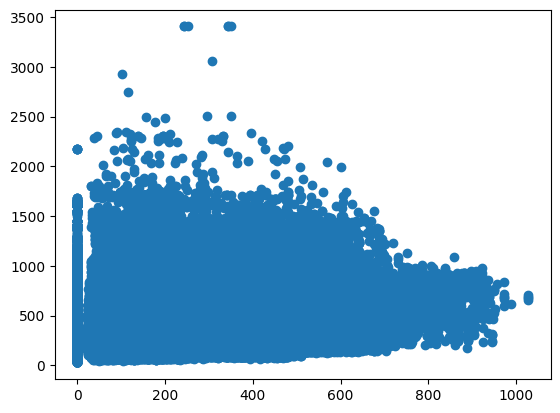

In [5]:
plt.scatter(data.layoverDurationMinutes, data.totalFare)
plt.show()

In [6]:
t = data[data.layoverDurationMinutes < 0]
x = ((t.segmentsArrivalTime - t.segmentsDepartureTime) / 1e9 / 60)
# t

In [7]:
def calc_lay(row):
    return int(sum((row)))

In [ ]:
x_ = x.apply(calc_lay)

In [14]:
x_

Series([], dtype: object)

In [17]:
t[(abs(t.layoverDurationMinutes) != x_) & (t.numLayovers == 2)]

,legId,searchDate,flightDate,startingAirport,destinationAirport,numDaysToFlight,numLayovers,layoverDurationMinutes,seatsRemaining,travelDuration,...,segmentsDepartureTime,segmentsArrivalTime,segmentsArrivalAirportCode,segmentsDepartureAirportCode,segmentsAirlineName,segmentsAirlineCode,segmentsAircraft,segmentsDurationInMinutes,segmentsDistance,segmentsCabinCode


In [18]:
sorted(data.layoverDurationMinutes)

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [19]:
abs(t.layoverDurationMinutes) - x_

Series([], dtype: object)

In [20]:
data.drop(columns="legId", inplace=True)

In [23]:
airmap = pd.read_csv("data/airportsData.csv")

In [24]:
data.columns

Index(['searchDate', 'flightDate', 'startingAirport', 'destinationAirport',
       'numDaysToFlight', 'numLayovers', 'layoverDurationMinutes',
       'seatsRemaining', 'travelDuration', 'totalTravelDistance',
       'elapsedDays', 'isBasicEconomy', 'isRefundable', 'isNonStop',
       'baseFare', 'totalFare', 'segmentsDepartureTime', 'segmentsArrivalTime',
       'segmentsArrivalAirportCode', 'segmentsDepartureAirportCode',
       'segmentsAirlineName', 'segmentsAirlineCode', 'segmentsAircraft',
       'segmentsDurationInMinutes', 'segmentsDistance', 'segmentsCabinCode'],
      dtype='str')

In [25]:
data['flightDate'] = pd.to_datetime(data['flightDate'])
data['searchDate'] = pd.to_datetime(data['searchDate'])
data['numDaysToFlight'] = (data.flightDate - data.searchDate).dt.days.astype('int32')

# Reorder: insert numDaysToFlight right after destinationAirport
cols = data.columns.tolist()
cols.remove('numDaysToFlight')
idx = cols.index('destinationAirport')
cols.insert(idx + 1, 'numDaysToFlight')
data = data[cols]

In [26]:
data.numDaysToFlight.max()

np.int32(60)

In [27]:
data.dtypes

searchDate                      datetime64[s]
flightDate                      datetime64[s]
startingAirport                           str
destinationAirport                        str
numDaysToFlight                         int32
numLayovers                             int32
layoverDurationMinutes                  int32
seatsRemaining                          int32
travelDuration                          int32
totalTravelDistance                     int32
elapsedDays                             int32
isBasicEconomy                           bool
isRefundable                             bool
isNonStop                                bool
baseFare                              float64
totalFare                             float64
segmentsDepartureTime                  object
segmentsArrivalTime                    object
segmentsArrivalAirportCode             object
segmentsDepartureAirportCode           object
segmentsAirlineName                    object
segmentsAirlineCode               

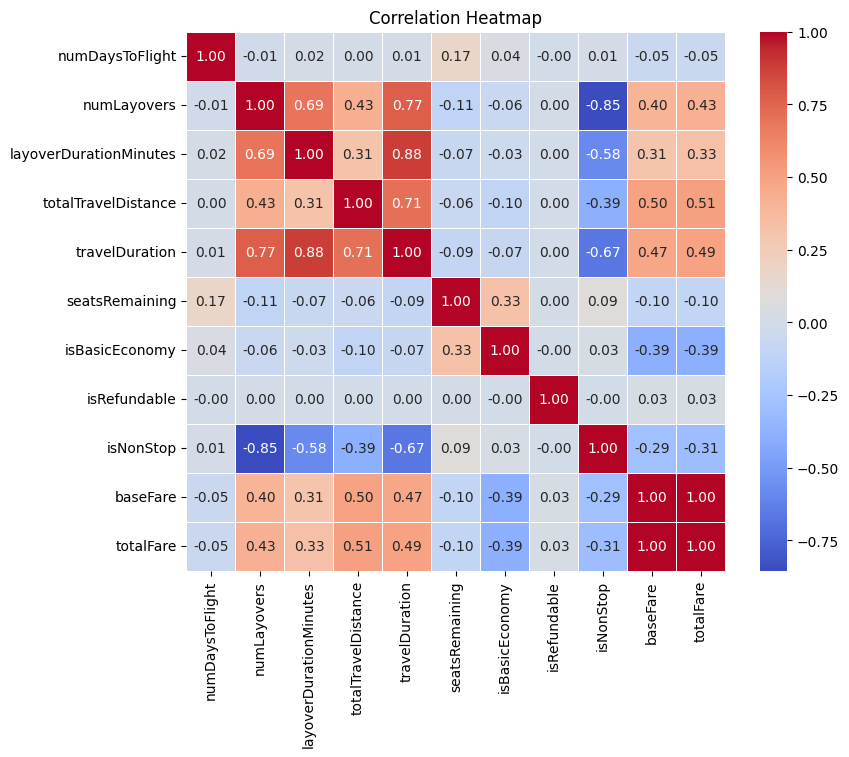

In [32]:
corr_cols = [
    "numDaysToFlight",
    "numLayovers",
    "layoverDurationMinutes",
    "totalTravelDistance",
    "travelDuration",
    "seatsRemaining",
    "isBasicEconomy",
    "isRefundable",
    "isNonStop",
    "baseFare",
    "totalFare",
]
plt.figure(figsize=(9, 7))
sns.heatmap(data[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.savefig("feature_correlation_heatmap.png", dpi=300)
plt.show()

In [30]:
data.columns

Index(['searchDate', 'flightDate', 'startingAirport', 'destinationAirport',
       'numDaysToFlight', 'numLayovers', 'layoverDurationMinutes',
       'seatsRemaining', 'travelDuration', 'totalTravelDistance',
       'elapsedDays', 'isBasicEconomy', 'isRefundable', 'isNonStop',
       'baseFare', 'totalFare', 'segmentsDepartureTime', 'segmentsArrivalTime',
       'segmentsArrivalAirportCode', 'segmentsDepartureAirportCode',
       'segmentsAirlineName', 'segmentsAirlineCode', 'segmentsAircraft',
       'segmentsDurationInMinutes', 'segmentsDistance', 'segmentsCabinCode'],
      dtype='str')

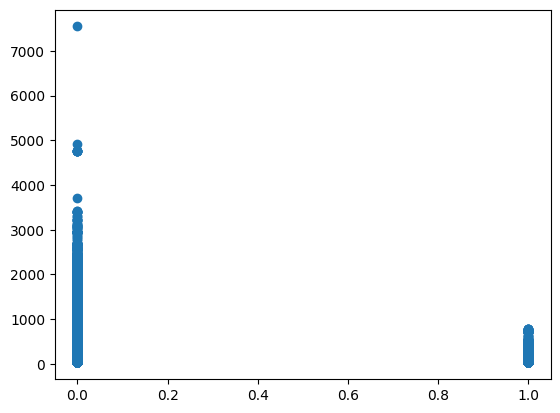

In [144]:
plt.scatter(data.isBasicEconomy, data.totalFare)
plt.show()

In [121]:
((data.totalFare - data.baseFare) / data.baseFare * 100).sort_values(ascending=False)

709504    161.497890
710049    131.962025
641539    116.679132
728149    110.788822
599178    103.280840
             ...    
105582      7.831303
180775      7.831303
172401      7.831303
180681      7.831303
708222      7.819757
Length: 747237, dtype: float64

In [10]:
data.startingAirport.unique()

<ArrowStringArray>
['ATL', 'BOS', 'CLT', 'DEN', 'DFW', 'DTW', 'EWR', 'IAD', 'JFK', 'LAX', 'LGA',
 'MIA', 'OAK', 'ORD', 'PHL', 'SFO']
Length: 16, dtype: str

In [11]:
data.destinationAirport.unique()

<ArrowStringArray>
['DFW', 'EWR', 'IAD', 'LAX', 'MIA', 'ORD', 'LGA', 'ATL', 'DTW', 'BOS', 'DEN',
 'JFK', 'SFO', 'CLT', 'OAK', 'PHL']
Length: 16, dtype: str

In [13]:
airports = []

for ap in data.segmentsArrivalAirportCodes:
    for a in ap:
        airports.append(a)

airportsList = set(airports)

In [18]:
for e in data.startingAirport.unique():
    airportsList.add(e)

for e in data.destinationAirport.unique():
    airportsList.add(e)

In [24]:
print(f"Total airports: {len(airportsList)}.")

Total airports: 189.


In [ ]:
data.startingAirport.value_counts().sort_values(ascending=False)

startingAirport
LAX    70186
LGA    55860
BOS    55413
SFO    54921
CLT    52276
ORD    49836
DFW    49517
ATL    44912
DEN    43776
MIA    43692
JFK    42736
PHL    42400
DTW    40169
EWR    34515
IAD    33617
OAK    33411
Name: count, dtype: int64

In [125]:
data.shape

(747237, 26)

In [ ]:
vc = data.startingAirport.value_counts().reset_index()
vc.columns = ["AirportCode", "Count"]
vc = vc.merge(airmap[["AirportCode", "City"]], on="AirportCode", how="left")
vc = vc[["AirportCode", "City", "Count"]]
vc

,AirportCode,City,Count
0,LAX,Los Angeles,70186
1,LGA,New York (LaGuardia),55860
2,BOS,Boston,55413
3,SFO,San Francisco,54921
4,CLT,Charlotte,52276
5,ORD,Chicago (O'Hare),49836
6,DFW,Dallas/Fort Worth,49517
7,ATL,Atlanta,44912
8,DEN,Denver,43776
9,MIA,Miami,43692


In [44]:
airlines = []

for ar in data.segmentsAirlineNames:
    for a in ar:
        airlines.append(a)

In [49]:
airlines1 = pd.Series(airlines)

In [51]:
airlines1.value_counts()

American Airlines           428667
Delta                       368902
United                      366703
JetBlue Airways              99942
Alaska Airlines              85339
Frontier Airlines            14874
Cape Air                      4345
Southern Airways Express      1386
Key Lime Air                  1064
Boutique Air                   986
Sun Country Airlines           362
Contour Airlines               190
Name: count, dtype: int64

In [12]:
data.loc[(data.startingAirport == 'LGA') & (data.destinationAirport == 'LAX')].sort_values("travelDurationMinutes", ascending=True)

,legId,searchDate,flightDate,startingAirport,destinationAirport,numDaysToFlight,numStops,layoverDurationMinutes,totalTravelDistance,travelDurationMinutes,...,segmentsDepartureTime,segmentsArrivalTime,segmentsArrivalAirportCodes,segmentsDepartureAirportCodes,segmentsAirlineNames,segmentsAirlineCodes,segmentsEquipmentDescriptions,segmentsDurationSeconds,segmentsDistances,segmentsCabinCodes
214377,29f505c0b1447d2f156fe38daaada144,2022-06-13,2022-07-08,LGA,LAX,25,1,43,2470,425,...,"[2022-07-08T20:30:00.000000000, 2022-07-08T23:...","[2022-07-08T23:07:00.000000000, 2022-07-09T03:...","[STL, LAX]","[LGA, STL]","[American Airlines, American Airlines]","[AA, AA]","[Airbus A319, Airbus A319]","[9420, 13500]","[881, 1589]","[coach, coach]"
260771,7297699d36213a430854d59bbdabb540,2022-06-23,2022-07-27,LGA,LAX,34,1,43,2470,425,...,"[2022-07-27T20:30:00.000000000, 2022-07-27T23:...","[2022-07-27T23:07:00.000000000, 2022-07-28T03:...","[STL, LAX]","[LGA, STL]","[American Airlines, American Airlines]","[AA, AA]","[Airbus A319, Airbus A319]","[9420, 13500]","[881, 1589]","[coach, coach]"
205703,9f61cd6ca678fdbaf82a2e306605cf99,2022-06-11,2022-07-19,LGA,LAX,38,1,43,2470,425,...,"[2022-07-19T20:30:00.000000000, 2022-07-19T23:...","[2022-07-19T23:07:00.000000000, 2022-07-20T03:...","[STL, LAX]","[LGA, STL]","[American Airlines, American Airlines]","[AA, AA]","[Airbus A319, Airbus A319]","[9420, 13500]","[881, 1589]","[coach, coach]"
268122,dfb025d6ef5ecb8dccd9b5c3be5b6119,2022-06-25,2022-08-04,LGA,LAX,40,1,43,2470,425,...,"[2022-08-04T20:30:00.000000000, 2022-08-04T23:...","[2022-08-04T23:07:00.000000000, 2022-08-05T03:...","[STL, LAX]","[LGA, STL]","[American Airlines, American Airlines]","[AA, AA]","[Airbus A319, Airbus A319]","[9420, 13500]","[881, 1589]","[coach, coach]"
108905,e5e8301505bf0d52868003787d17737e,2022-05-12,2022-06-17,LGA,LAX,36,1,43,2470,425,...,"[2022-06-17T20:30:00.000000000, 2022-06-17T23:...","[2022-06-17T23:07:00.000000000, 2022-06-18T03:...","[STL, LAX]","[LGA, STL]","[American Airlines, American Airlines]","[AA, AA]","[Airbus A319, Airbus A319]","[9420, 13500]","[881, 1589]","[coach, coach]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,cfad26e956fd5eb88d96f28e8bc9d0cb,2022-04-16,2022-04-17,LGA,LAX,1,2,559,2567,1035,...,"[2022-04-17T23:10:00.000000000, 2022-04-18T02:...","[2022-04-18T00:35:00.000000000, 2022-04-18T04:...","[IAD, BNA, LAX]","[LGA, IAD, BNA]","[United, United, Alaska Airlines]","[UA, UA, AS]","[, Embraer 175 (Enhanced Winglets), Airbus A321]","[5100, 6720, 16740]","[221, 552, 1794]","[coach, coach, coach]"
374264,50e7c66df6c17534f8042a77b43e5541,2022-07-16,2022-09-11,LGA,LAX,57,2,572,2809,1046,...,"[2022-09-11T10:00:00.000000000, 2022-09-11T15:...","[2022-09-11T12:19:00.000000000, 2022-09-11T17:...","[ATL, AUS, LAX]","[LGA, ATL, AUS]","[Delta, Delta, Alaska Airlines]","[DL, DL, AS]","[Airbus A320, Airbus A321, Boeing 737-800]","[8340, 8340, 11760]","[762, 811, 1236]","[coach, coach, coach]"
430459,248b36f51f4258ad8a353a94fe357b8e,2022-07-27,2022-09-11,LGA,LAX,46,2,572,2809,1055,...,"[2022-09-11T10:00:00.000000000, 2022-09-11T13:...","[2022-09-11T12:19:00.000000000, 2022-09-11T16:...","[ATL, AUS, LAX]","[LGA, ATL, AUS]","[Delta, Delta, Alaska Airlines]","[DL, DL, AS]","[Airbus A320, Airbus A321, Boeing 737-800]","[8340, 8340, 12300]","[762, 811, 1236]","[coach, coach, coach]"
259939,50f9363da9e5354fe0d7916fd4dccc5f,2022-06-23,2022-07-16,LGA,LAX,23,2,577,2470,1066,...,"[2022-07-16T20:52:00.000000000, 2022-07-17T02:...","[2022-07-16T23:49:00.000000000, 2022-07-17T06:...","[ORD, LAS, LAX]","[LGA, ORD, LAS]","[United, United, United]","[UA, UA, UA]","[Embraer 175 (Enhanced Winglets), Boeing 737-8...","[10620, 14040, 4680]","[720, 1509, 241]","[coach, coach, coach]"


In [ ]:
data.flightDate.sort_values().iloc[-1]

Timestamp('2022-11-19 00:00:00')

In [ ]:
data.flightDate.sort_values().iloc[0]

Timestamp('2022-04-17 00:00:00')

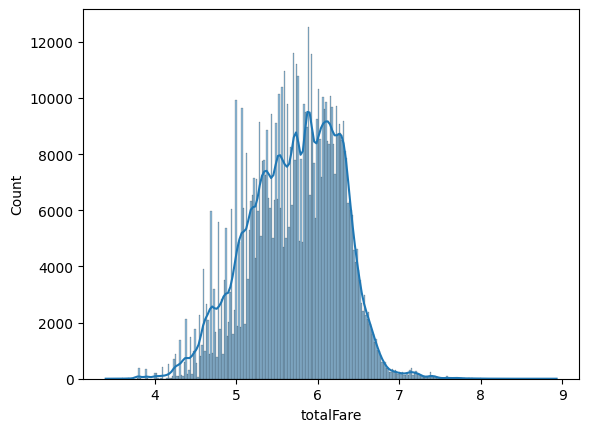

In [143]:
sns.histplot(np.log1p(data.totalFare), kde=True)
plt.show()

In [ ]:
all_airports = set(data['startingAirport'].unique()) | set(data['destinationAirport'].unique())

for col in ['segmentsArrivalAirportCodes', 'segmentsDepartureAirportCodes']:
    for arr in data[col]:
        all_airports.update(arr)

print(f"Total unique airport codes across all fields: {len(all_airports)}")
print(sorted(all_airports))

Total unique airport codes across all fields: 189
['ABQ', 'ACK', 'ACV', 'AGS', 'ALB', 'ATL', 'ATW', 'ATY', 'AUS', 'AVL', 'AVP', 'BDL', 'BFD', 'BFL', 'BGR', 'BHM', 'BIL', 'BJC', 'BMI', 'BNA', 'BOI', 'BOS', 'BTR', 'BTV', 'BUF', 'BUR', 'BWI', 'BZN', 'CAE', 'CEZ', 'CHA', 'CHO', 'CHS', 'CID', 'CKB', 'CLE', 'CLT', 'CMH', 'CNM', 'COS', 'COU', 'CSG', 'CVG', 'CVN', 'DAL', 'DAY', 'DCA', 'DEN', 'DFW', 'DSI', 'DSM', 'DTW', 'DUJ', 'ELD', 'ELP', 'EUG', 'EVV', 'EWR', 'EYW', 'FAT', 'FAY', 'FCA', 'FLL', 'FNT', 'FSD', 'FWA', 'GEG', 'GLH', 'GNV', 'GPT', 'GRB', 'GRR', 'GSO', 'GSP', 'GTF', 'HHH', 'HLN', 'HOB', 'HOT', 'HPN', 'HRO', 'HSV', 'HYS', 'IAD', 'IAH', 'ICT', 'ILM', 'IMT', 'IND', 'IPL', 'JAC', 'JAN', 'JAX', 'JFK', 'LAS', 'LAX', 'LEX', 'LFT', 'LGA', 'LIT', 'LNK', 'LNS', 'MAF', 'MBS', 'MCI', 'MCO', 'MDT', 'MEM', 'MFR', 'MGM', 'MGW', 'MHK', 'MHT', 'MIA', 'MKE', 'MKL', 'MLI', 'MOB', 'MRY', 'MSN', 'MSO', 'MSP', 'MSS', 'MSY', 'MVY', 'MWA', 'MYR', 'OAK', 'OKC', 'OMA', 'ONT', 'ORD', 'ORF', 'OWB', 'PBI', 'PDX

In [13]:
data.to_parquet("data/flights_clean_1gb.parquet")